# Naive Concatenation Baseline (Expression + Methylation)

**Purpose:** Gene expression and DNA methylation are standardized independently and glued together into one wide feature matrix, so no joint modeling of shared structure across layers. Uses the same fixed reference cohort, CV folds, models, and evaluation metrics as `01_model_expression.ipynb` 

**Important key design:** concatenation happens **inside the CV loop**, with each layer's `StandardScaler` fit only on that fold's training data, because scaling before splitting into folds would leak test-fold information into the scaling statistics.

## 0. Set working directory (VS Code Jupyter quirk)

Edit the path if your project folder is different.

In [7]:
import os
os.chdir(r"C:\Users\sshor\Desktop\Data Science\NEWPROJECT\ML Scripts")
print(os.getcwd())


C:\Users\sshor\Desktop\Data Science\NEWPROJECT\ML Scripts


## 1. Imports

In [8]:
import numpy as np
from sklearn.preprocessing import StandardScaler
import common_utils as cu


## 2. Configuration

In [ ]:
cu.CONFIG["debug_mode"] =  False  # <-- flip to False for the real run

cu.CONFIG["reference_cohort_dir"] = "reference_cohort"

FEATURE_FILES = {
    "expression": "preprocessed_multiomics/expression_filtered.csv",
    "methylation": "preprocessed_multiomics/methylation_filtered.csv",
}

EXPERIMENT_NAME = "concatenated"


## 3. Load both layers

keeping only the common samples between the layers

In [10]:
layers, y, fold_arr, samples = cu.load_reference_cohort(feature_files=FEATURE_FILES)
for name, arr in layers.items():
    print(f"{name}: {arr.shape}")


Loaded 2 layers, 318 common samples, 5 folds.
expression: (318, 5000)
methylation: (318, 5000)


## 4. Per-fold feature builder

Each layer gets its own `StandardScaler`, fit ONLY on the training portion of whatever fold is currently running, then all layers are horizontally stacked into one wide matrix, without it whichever layer happens to have the larger raw numeric range would dominate the combined matrix for no biological reason.

In [11]:
def feature_builder(train_layers, test_layers):
    X_train_parts, X_test_parts = [], []
    for name in train_layers:
        scaler = StandardScaler().fit(train_layers[name])
        X_train_parts.append(scaler.transform(train_layers[name]))
        X_test_parts.append(scaler.transform(test_layers[name]))
    return np.hstack(X_train_parts), np.hstack(X_test_parts)


## 5. Run cross-validation

In [12]:
results = cu.run_cross_validation(layers, y, fold_arr, feature_builder=feature_builder, models=("coxnet", "rsf", "xgboost"))


[fold 0] coxnet   C-index=0.600  IBS=0.184  (alpha=0.06935)
[fold 0] rsf      C-index=0.653  IBS=0.164
[fold 0] xgboost  C-index=0.666  IBS=0.183
[fold 1] coxnet   C-index=0.646  IBS=0.236  (alpha=0.06341)
[fold 1] rsf      C-index=0.687  IBS=0.155
[fold 1] xgboost  C-index=0.697  IBS=0.193
[fold 2] coxnet   C-index=0.668  IBS=nan  (alpha=0.007353)
[fold 2] rsf      C-index=0.807  IBS=0.133
[fold 2] xgboost  C-index=0.811  IBS=0.161
[fold 3] coxnet   C-index=0.759  IBS=nan  (alpha=0.005099)
[fold 3] rsf      C-index=0.744  IBS=0.138
[fold 3] xgboost  C-index=0.757  IBS=0.151
[fold 4] coxnet   C-index=0.677  IBS=nan  (alpha=0.007812)
[fold 4] rsf      C-index=0.800  IBS=0.153
[fold 4] xgboost  C-index=0.799  IBS=0.148


## 6. Summary and comparison plot

In [13]:
cu.summarize_results(results)



=== Cross-validated performance (mean +/- std across folds) ===
coxnet    C-index = 0.670 +/- 0.052   IBS = 0.210 +/- 0.026  (3 fold(s) had unstable IBS, excluded)
rsf       C-index = 0.738 +/- 0.061   IBS = 0.148 +/- 0.011
xgboost   C-index = 0.746 +/- 0.056   IBS = 0.167 +/- 0.018


Saved model_comparison_concatenated.png


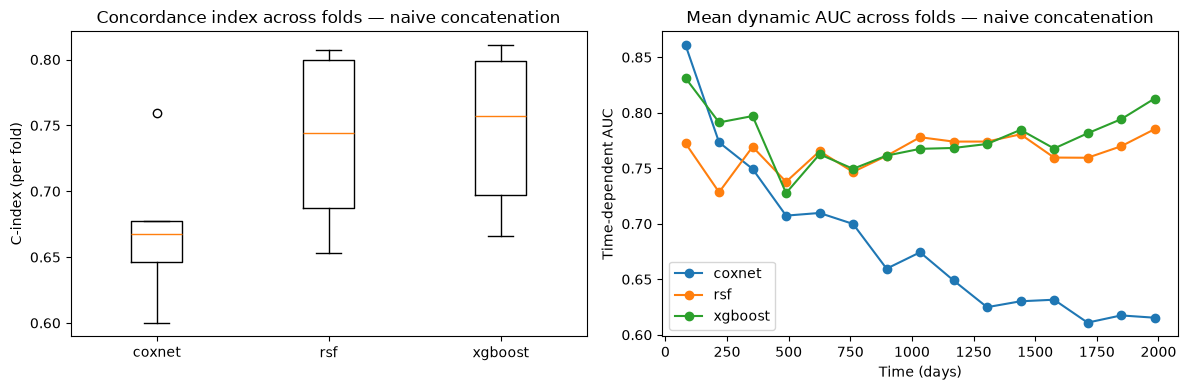

In [14]:
cu.plot_comparison(results, title_suffix=" — naive concatenation",
                    save_path=f"model_comparison_{EXPERIMENT_NAME}.png")


## 7. Feature importance

Takes the full concatenated matrix for a final refit, with feature names prefixed by layer (e.g. `expression__TP53`, `methylation__cg00123456`).

In [15]:
combined_feature_names = []
combined_arrays = []
for name, arr in layers.items():
    combined_arrays.append(arr)
    #feature_names are rebuild them from the original file columns
    import pandas as pd
    cols = pd.read_csv(FEATURE_FILES[name], index_col=0, nrows=0).columns
    if cu.CONFIG["debug_mode"]:
        #match the same top-variance subsetting applied inside load_reference_cohort
        debug_cfg = cu._debug_scaled_config()
        if debug_cfg["n_top_features"] and debug_cfg["n_top_features"] < len(cols):
            full_df = pd.read_csv(FEATURE_FILES[name], index_col=0).loc[samples]
            top_cols = full_df.var(axis=0).sort_values(ascending=False).head(debug_cfg["n_top_features"]).index
            cols = top_cols
    combined_feature_names.extend([f"{name}__{c}" for c in cols])

X_combined = np.hstack(combined_arrays)
combined_feature_names = np.array(combined_feature_names)
print(f"Combined matrix: {X_combined.shape}, {len(combined_feature_names)} feature names")
assert X_combined.shape[1] == len(combined_feature_names), "feature name count mismatch -- check debug-mode subsetting logic above"


Combined matrix: (318, 10000), 10000 feature names


Elastic-Net Cox (full-data refit): alpha=0.06081, 80 nonzero features out of 10000


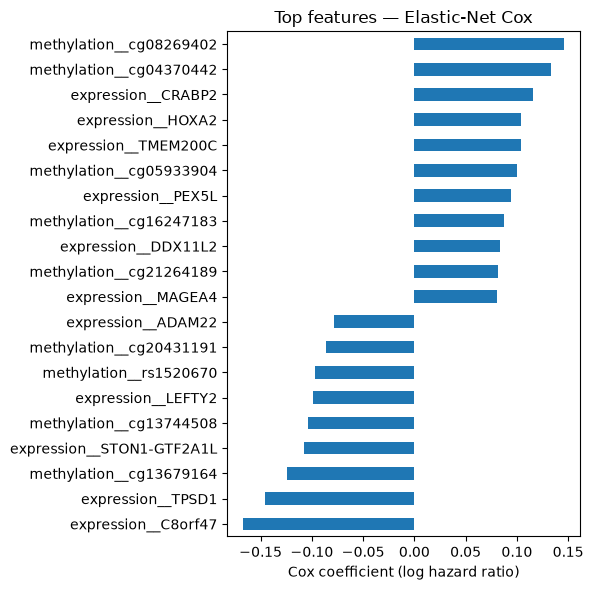

In [16]:
nonzero_coefs = cu.feature_importance_coxnet(X_combined, y, combined_feature_names, save_prefix=EXPERIMENT_NAME)


RSF permutation importance computed on top 300 (by variance) of 10000 total features.


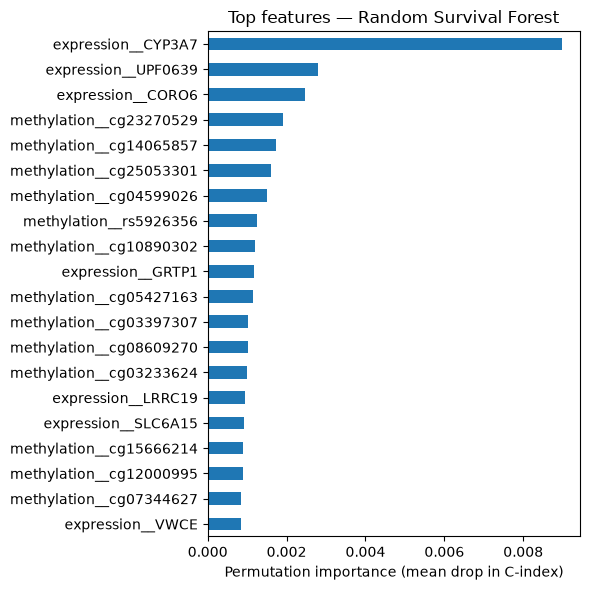

In [17]:
importances_rsf = cu.feature_importance_rsf(X_combined, y, combined_feature_names, save_prefix=EXPERIMENT_NAME)


XGBoost-Cox (full-data refit): 518 features with nonzero importance out of 10000


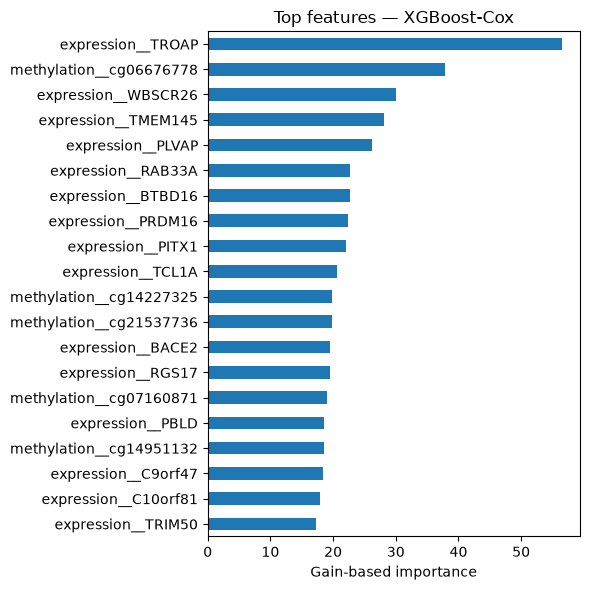

In [19]:
xgb_importances = cu.feature_importance_xgboost(X_combined, y, combined_feature_names, save_prefix=EXPERIMENT_NAME)

## 8. Save results for the final 3-way comparison (notebook 04)

In [20]:
cu.save_results(EXPERIMENT_NAME, results)


Saved results to results\results_concatenated.pkl
